# Bayesian Optimization : Full Search

**Summary**: This code implements bayesopt.py to optimize the SSN given some simulated sample data. It walks through how to implement bayesopt.py as well as gives some inutiition about how it works under the hood. For a basic introduction to Bayesian optimization see [BayesianOptimization_demo.ipynb](BayesianOptimization_demo.ipynb).

## Motivation

Running simulations of large stabilized supralinear networks (SSNs) is computationally costly making direct fitting to data difficult for large networks. To improve the efficiency of the optimization procedure we can used better informed choices of parameters by modeling the cost function in parameter space. This model gives us an estimate of what the cost will be for various parameter combinations without exhaustively sampling the parameter space. We can then choose parameters to maximizing the fit and provide maximal information about the cost function.

I first need to see if this will even work in principle, so I'm working with a moderately scaled-down model (64 E neurons, 64 I neurons). I have some target data that has been generated by simulating this network given a set of predetermined parameters. I'm going to test whether I can find these parameters starting with a randomly initialized networks and iteratively improving the fit using Bayesian Optimization.

## Process

In plain language, the algorithm is a kind of expedited random search where the search points are prioritized according to an explicit model of the cost landscape and feasibility of parameters. Here is how it works:

1) Randomly select a number of parameter sets for the model over some prior distribution.
2) For each parameter determine if the parameter set is feasible
3) If it's feasible, compute the cost function between the model outputs and the target data.
4) Fit a Gaussian process to the cost samples to model the cost landscape.
5) Define an acquisition function (we use expected improvement) that balances two goals, minimize the cost (exploit) and increase information about the cost function (explore). We also add in an additional requirement that the parameters have to be feasible. Take the max of this acquisition function to get a new parameterization.
6) Repeat 2-5 some finite number of times and take the one with the min cost

## Algorithm

**Algorithm**:

**Input**:  
- Search region $\Theta$  
- Maximum number of iterations K
- R number of simulations to run

---

**Initialization**  
1. Sample 5 initial parameter sets, either uniformly at random or according to a prior distribution. Let this set be $\hat{\theta}$ (theta-hat).  
2. For each $\theta \in \hat{\theta}$:
   - Let each simulation cost be $\hat{c}(\theta)_r, r = 1..R$.
   - Determine the feasibility:
       Assign to each $\theta$ a feasibility value ranging from $\hat{g}(\theta) = 0$ to $\hat{g}(\theta) = 0$; for N/R given N of possible R simulation that are feasible
   - Define the estimated cost:  
       $\hat{c}(\theta) = \frac{1}{R}\sum_{r=1}^{R} \hat{c}(\theta)_r$
3. Define $\hat{C} = { \hat{c}(\theta) : \theta \in \hat{\theta}}$ and $\hat{G} = { \hat{g}(\theta) : \theta \in \hat{\theta}}$.

---

**Main Loop**  
For k = 1..K:
1. Fit a Gaussian Process (GP) to ($\hat{theta}$, $\hat{G}$)
2. Fit a GP to ($\hat{\theta}$, $\hat{C}$).  
3. For all $\theta \in \Theta$, compute the acquisition function $a(\theta)$ (Expected Improvement).  
4. Pick $\theta_k = \arg\max a(\theta)$.  
5. Run R simulations for $\theta_k$ to get $\hat{c}(\theta_k)_r$ and $\hat{g}(\theta_k)_r$, $r = 1..R$.  
6. if $\hat{g}(\theta_k)$ > 0, average the costs across all feasible simulations:  
     $\hat{c}(\theta_k) = \frac{1}{R}\sum_{r=1}^{R} \hat{c}(\theta_k)_r$
     ; Otherwise, set $\hat{c}(\theta_k) = 10^9$.
7. Update $\hat{\theta} \leftarrow \hat{\theta} \cup {\theta_k}$, $\hat{C} \leftarrow \hat{C} \cup {\hat{c}(\theta_k)}$, $\hat{G} \leftarrow \hat{G} \cup {\hat{g}(\theta_k)}$.

---

**Return**  
  $\theta^* = \arg\min_{\theta \in \hat{\theta}} \hat{c}(\theta).$

## Set Main Directory

In [ ]:
mainDir = '.'
SSNDir = '../' #path to directory with SSN code

## Add Paths

In [ ]:
import sys
sys.path.insert(1, mainDir)
sys.path.append(SSNDir)

## Imports

In [ ]:
import numpy as np
import json
import pandas as pd
import os
import ssn_v1.SSN_utils as SSN_utils
from ssn_v1.SSN import SSN, NumericalInstabilityError
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
import h5py
import paramiko
import matplotlib.pyplot as plt
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import h5py
import errno
import paramiko
import tempfile
from scipy.special import rel_entr
from scipy.stats import norm
from ssn_v1.bayesopt import bayesopt

In [ ]:
# Check pwd
os.system('pwd')

/Users/Joe/Documents/GitHub/ssn-v1/bayesopt_demo


0

# Get Target Data

First we need to grab some target data. We'll use some target data that was generated by this network.

In [ ]:
# Import target data

with open(os.path.join(mainDir, 'target_data','test_target_data.json'), 'r') as f:
    target_data = json.load(f)

In [ ]:
# Organize data

# Convert target_data to target_data_mat
num_files = len(target_data["stim_labels"])
valid_keys = [key for key in target_data if str(key).isdigit()]
num_indices = len(valid_keys)
target_data_mat = np.zeros((num_files, num_indices))

for key in valid_keys:
    col_idx = int(key)
    for v_i, value in enumerate(target_data[key]["stim"]["mean"]):
        target_data_mat[v_i, col_idx] = value[0]
        
target_data_mat = target_data_mat.T

# Initialize Network

Next we need to initialize an SSN. See [other documentation](../sandbox/SSN_tutorial.ipynb) for an explainer on this process using SSN.py.

In [ ]:
model_name = '20250219grid'
experiment_name = 'flexCRF'
config = 'config.'+model_name+'.'+experiment_name+'.json'
overwrite_outputs = False
V1net = SSN("ei_model")
V1net.load_config(os.path.join(mainDir,config))
print(f"Loading {config}")

SSN WARNING: No input configuration file specified in config. Using default input configuration.
SSN WARNING: Input configuration file not found at ./inputs/flexCRF/./inputs/config.inputs.json. Using default input configuration.
Loading config.20250219grid.flexCRF.json


We need to randomize the free parameters. But let's restrict the choice of parameters to ones with stable solutions with ISN dynamics.

We could do this be enforcing a few rules from Ahmadian et al. (2013) and Ekelmans et al. (2023). But for now, let's stick to a simpler threshold and just enforce the bounds manually.

In [ ]:
# E <-- E
V1net.parameters['edges']['spatial_tuning']['E<-E']['kappa'] = 0.1 #0.2 #0.8
V1net.parameters['edges']['spatial_tuning']['E<-E']['sigma'] = 8 #10
V1net.parameters['edges']['spatial_tuning']['E<-E']['j'] = 0.05 #0.1 #0.01
V1net.parameters['edges']['func_tuning']['E<-E']['sigma_ori'] = 0.7853981633974483 #0.5

# E <-- I
V1net.parameters['edges']['spatial_tuning']['E<-I']['kappa'] = 0.5 #0.8
V1net.parameters['edges']['spatial_tuning']['E<-I']['sigma'] = 4 #10
V1net.parameters['edges']['spatial_tuning']['E<-I']['j'] = -0.460 #-0.092 #-0.01
V1net.parameters['edges']['func_tuning']['E<-I']['sigma_ori'] = 0.7853981633974483 #0.5

# I <-- E
V1net.parameters['edges']['spatial_tuning']['I<-E']['kappa'] = 0.1 #0.8
V1net.parameters['edges']['spatial_tuning']['I<-E']['sigma'] = 12 #10
V1net.parameters['edges']['spatial_tuning']['I<-E']['j'] = 1.9 #0.38 #0.01
V1net.parameters['edges']['func_tuning']['I<-E']['sigma_ori'] = 0.7853981633974483 #0.5

# I <-- I
V1net.parameters['edges']['spatial_tuning']['I<-I']['kappa'] = 0.5 #0.8
V1net.parameters['edges']['spatial_tuning']['I<-I']['sigma'] = 4 #10
V1net.parameters['edges']['spatial_tuning']['I<-I']['j'] = -0.445 #-0.089 #-0.01
V1net.parameters['edges']['func_tuning']['I<-I']['sigma_ori'] = 0.7853981633974483 #0.5

theta = np.array([V1net.parameters['edges']['spatial_tuning']['E<-E']['kappa'],
        V1net.parameters['edges']['spatial_tuning']['E<-E']['sigma'],
        V1net.parameters['edges']['spatial_tuning']['E<-E']['j'],
        V1net.parameters['edges']['func_tuning']['E<-E']['sigma_ori'],
        V1net.parameters['edges']['spatial_tuning']['E<-I']['kappa'],
        V1net.parameters['edges']['spatial_tuning']['E<-I']['sigma'],
        V1net.parameters['edges']['spatial_tuning']['E<-I']['j'],
        V1net.parameters['edges']['func_tuning']['E<-I']['sigma_ori'],
        V1net.parameters['edges']['spatial_tuning']['I<-E']['kappa'],
        V1net.parameters['edges']['spatial_tuning']['I<-E']['sigma'],
        V1net.parameters['edges']['spatial_tuning']['I<-E']['j'],
        V1net.parameters['edges']['func_tuning']['I<-E']['sigma_ori'],
        V1net.parameters['edges']['spatial_tuning']['I<-I']['kappa'],
        V1net.parameters['edges']['spatial_tuning']['I<-I']['sigma'],
        V1net.parameters['edges']['spatial_tuning']['I<-I']['j'],
        V1net.parameters['edges']['func_tuning']['I<-I']['sigma_ori']])

Let's also get the cell type labels in a format that is similar to the format used for the real data.

In [ ]:
V1net.add_nodes()

Config file already loaded. Adding nodes...
Creating OriMap - kc = 1, nMap = 30, map_seed = None


In [ ]:
nodeTypes = V1net.node_types['model_type_name'].values

nodeTypeArray = np.zeros((len(V1net.nodes),len(nodeTypes)))

for nT_i, nT in enumerate(nodeTypes):
    nodeTypeArray[:,nT_i] = V1net.nodes['model_name'].values == nT

### Generate Stimulus

Loading the files is taking far too long. Let's just create the stimuli from scratch.

Text(0, 0.5, 'h(t)')

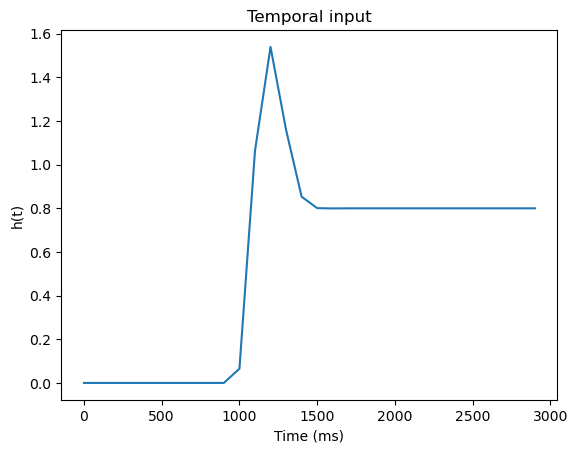

In [ ]:
from ssn_v1 import designStim

# Create Temporal Response Function
T = 3000. #10000. #total duration (ms)
V1net.run_params['tstop'] = T #we need to make sure that the run params are consistent with the config file
fs_input = V1net.inputs_config['sampling_rate'] #sampling rate of inputs in Hz
t_step_input = 1000/fs_input
t = np.arange(0,T,t_step_input)
m1 = 170 #mean of first Gaussian
s1 = 100 #st. dev. of first Gaussian
A1 = 1 #amplitude of first Gaussian
m2 = -200 #mean of second Gaussian
s2 = 200 #st. dev. of second Gaussian
A2 = 1.6 #amplitude of second Gaussian
C = 0.8 #offset
t_delay = 1000 #time delay (ms)

t_response = designStim.transient_sustained(T=T,t_steps=t_step_input,m1=m1,s1=s1,A1=A1,m2=m2,s2=s2,A2=A2,C=C,t_delay=t_delay)

# Plot
fig, ax = plt.subplots()
ax.plot(t, t_response)
ax.set_title("Temporal input")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("h(t)")

Next, I'll add orientation tuning.

Text(0.5, 0, 'Orientation (deg)')

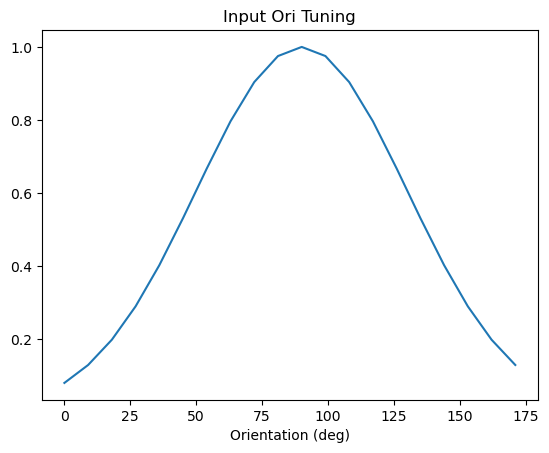

In [ ]:
Ntheta = 20 #number of orientation channels
theta_ori = np.linspace(0,180-180/Ntheta,Ntheta) #orientations
theta_stim = 90 #stimulus orientation
cycle = 180 #degrees per cycle
sigma = 40 #st. dev. for a circular Gaussian

ori_scaling = SSN_utils.circGauss(theta_ori, theta_stim, sigma, cycle)

# Plot
fig, ax = plt.subplots()
ax.plot(theta_ori,ori_scaling)
ax.set_title("Input Ori Tuning")
ax.set_xlabel("Orientation (deg)")

In [ ]:
# Apply orientation tuning to input array

NX = 2**8
NY = 2**8
ori_kernel_params = {"kernelType": SSN_utils.circGauss, #kernel type
             "args": [theta_stim,sigma,cycle,theta_ori], #positional arguments
             "kwargs": {} #keyword arguments
             }
t_params = {"kernelType": designStim.transient_sustained, #kernel function
                "args": [], #positional arguments
                "kwargs": {"T":T, "t_steps":t_step_input, "m1": m1, "s1": s1, "A1": A1, "m2": m2, "s2": s2, "A2": A2, "C": C, "t_delay": t_delay}} #keyword arguments
inputs = designStim.drive_orientation(NX,NY,ori_kernel_params,t_params)

np.shape(inputs)

(256, 256, 30, 20)

In [ ]:
stim_labels = np.array(target_data['stim_labels'])

[ 0. 90.]


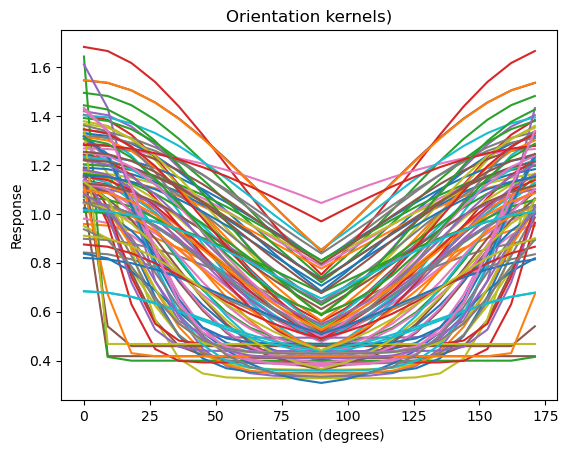

In [ ]:
import importlib
importlib.reload(designStim)

# Parameters for orientation sweep
Norientations = len(np.unique(stim_labels[:,0])) #number of stimulus orientations (this should match with the data)
orientations = np.unique(stim_labels[:,0]) #stimulus orientations
NT = int(np.floor(T/t_step_input))
print(orientations)

# Orientation kernel params
Ntheta = 20
theta_ori = np.linspace(0,180-180/Ntheta,Ntheta)
cycle = 180
sigma_mean = 40 #mean tuning width; see above for explanation on how these values were derived
sigma_std = 26 #st. dev. tuning width; see above for explanation on how these values were derived
scale_mean = 1.0 #mean scale of inputs
scale_std = 0.2 #st. dev. scale of inputs
offset_mean = 0.5 #0.1 #mean offset of inputs
offset_std = 0.05 #st. dev. offset of inputs
mu_std = 0 #st. dev. stim orientation
ori_kernel_func = designStim.generate_orientation_kernels #set orientation kernel function; this one will sample random kernels from a circular Gaussian
t_kernel_func = designStim.transient_sustained #temporal kernel function

oriExp_inputs = np.zeros((NX, NY, NT, Ntheta, Norientations)) #initialize matrix to hold inputs
for o_i, ori in enumerate(orientations):
    
    #set stim orientation
    mu_mean = ori #stim orientation
    
    #define kernel params
    ori_kernel_params = {"kernelType": ori_kernel_func, #kernel function
                         "args": [theta_ori,NX,NY,mu_mean,mu_std,sigma_mean,sigma_std,scale_mean,scale_std,offset_mean,offset_std], #positional arguments
                         "kwargs": {"seed": 123}} #keyword arguments
    t_params = {"kernelType": t_kernel_func, #kernel function
                "args": [], #positional arguments
                "kwargs": {"T":T, "t_steps":t_step_input, "m1": m1, "s1": s1, "A1": A1, "m2": m2, "s2": s2, "A2": A2, "C": C, "t_delay": t_delay}} #keyword arguments
    
    oriExp_inputs[:,:,:,:,o_i] = designStim.drive_orientation(NX,NY,ori_kernel_params,t_params)

# Plot an example orientation kernel for a specific spatial position (e.g., center of the image)
all_curves = oriExp_inputs[:,:,-1,:,int(np.round(Norientations/4))].reshape((NX*NY,Ntheta)).T
sample_curves = all_curves[:,np.random.choice(NX*NY, size=100)]
plt.figure()
plt.plot(theta_ori, sample_curves)
plt.title("Orientation kernels)")
plt.xlabel("Orientation (degrees)")
plt.ylabel("Response")
plt.show()

Text(0, 0.5, 'Count')

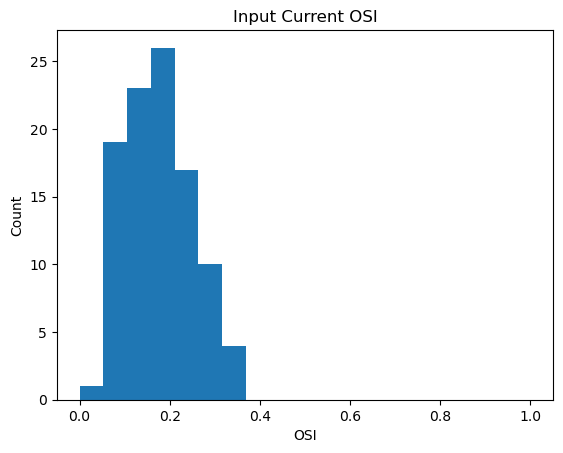

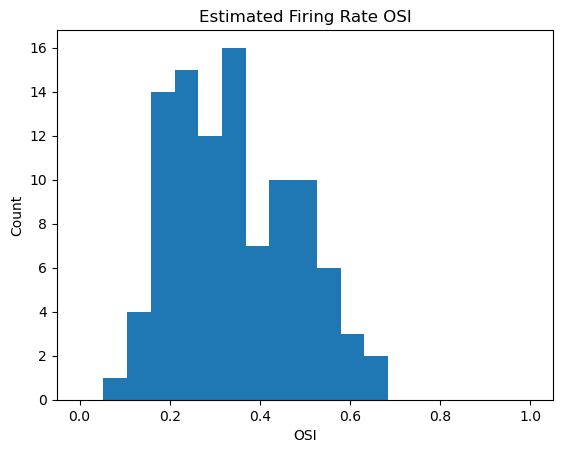

In [ ]:
def compute_OSI(responses, orientations, units='deg'):
    # Compute OSI
    #.   responses (array-like) - A vector or matrix of cell responses. First dimension is expected to be the same length as orientations
    #.   orientations (array-like) - A vector of orientations.
    #.   units (array-like) - Units for orientations (deg or rad)
    #.       DEFAULT - 'deg'
    #.
    #. Returns
    #.    OSI - orientation selectivity index
    #.    ori_pref - in requested units

    # Reshape responses if necessary
    if len(np.shape(responses)) == 1:
        responses = responses[:, np.newaxis]
    elif len(np.shape(responses)) > 2 or len(np.shape(responses)) < 1:
        print("compute_OSI: Unexpected shape for responses")

    # Compute the complex vectors for each orientation
    if units == 'deg':
        orientations = np.radians(orientations)
    orientations = np.mod(orientations, np.pi)
    complex_vectors = np.exp(2j * orientations[:, np.newaxis])  # shape (Norientations, 1)

    # Multiply the responses by their respective complex vectors
    weighted_vectors = responses * complex_vectors  # Broadcasting across cells

    # Compute the sum of vectors for each cell (along the orientation axis)
    vector_sum = np.sum(weighted_vectors, axis=0)

    # Compute the normalized vector sum (normalize by the sum of response magnitudes)
    response_magnitudes = np.sum(responses, axis=0)
    normalized_vector_sum = vector_sum / response_magnitudes

    # Return the normalized vector sum and its magnitude and phase (direction)
    OSI = np.abs(normalized_vector_sum)
    ori_pref = np.angle(normalized_vector_sum)/2
    ori_pref = np.mod(ori_pref,np.pi)
    if units == 'deg':
        ori_pref = np.degrees(ori_pref)

    return OSI, ori_pref

# Calculate OSI of sample

OSI_sample, ori_pref_sample = compute_OSI(sample_curves, theta_ori)

plt.figure()
plt.hist(OSI_sample,bins=np.linspace(0,1,20))
plt.title("Input Current OSI")
plt.xlabel('OSI')
plt.ylabel('Count')

OSI_sample_rate, ori_pref_sample_rate = compute_OSI(sample_curves**2, theta_ori)

plt.figure()
plt.hist(OSI_sample_rate,bins=np.linspace(0,1,20))
plt.title("Estimated Firing Rate OSI")
plt.xlabel('OSI')
plt.ylabel('Count')

In [ ]:
oriExp_inputs = np.transpose(oriExp_inputs,(4,0,1,2,3))

Scale the inputs so that they roughly match a firing rate maximum of 100.

In [ ]:
scale_inputs = 60
oriExp_inputs = scale_inputs*oriExp_inputs

Now save the orientation sweep to the ```inputs/``` directory. To reduce the amount of space occupied by the inputs, contrast will be manipulated by the parameter `c` in the model rather than creating scaled versions of the same inputs for each contrast.

In [ ]:
# Make flexCRF inputs

inputs_dir = V1net.manifest['$INPUTS_DIR'].replace('$BASE_DIR', V1net.manifest['$BASE_DIR'])
Ncontrasts = len(np.unique(stim_labels[:,1]))
contrasts = np.unique(stim_labels[:,1])
print(contrasts)
# if not os.path.exists(inputs_dir):
#     os.system(f'mkdir {inputs_dir}')
#     print(f"{inputs_dir} not found. Creating new directory")
# for o_i, ori in enumerate(orientations):
#     save_inputs = oriExp_inputs[o_i,:,:,:,:]
#     # Save the array to an HDF5 file
#     with h5py.File(os.path.join(inputs_dir,f'FullFieldGrating_orientation={ori}_contrast=1.0.h5'), 'w') as h5file:
#         h5file.create_dataset('inputs', data=save_inputs)

[0.01 1.  ]


In [ ]:
# Reformat inputs
conditions = target_data['stim_labels']
input_data = {}
for condition in conditions:
    ind = np.where(orientations == condition[0])[0]
    input_data[str(condition)] = np.squeeze(oriExp_inputs[ind,:,:,:,:])

In [ ]:
np.shape(input_data['[0.0, 0.01]'])

(256, 256, 30, 20)

(array([3.0145342e+07, 1.7291450e+07, 1.7551092e+07, 1.0500940e+07,
        1.9408280e+06, 7.6978200e+05, 3.4940200e+05, 8.6174000e+04,
        7.9580000e+03, 2.3200000e+02]),
 array([  0.        ,  22.17466739,  44.34933478,  66.52400217,
         88.69866955, 110.87333694, 133.04800433, 155.22267172,
        177.39733911, 199.5720065 , 221.74667389]),
 <BarContainer object of 10 artists>)

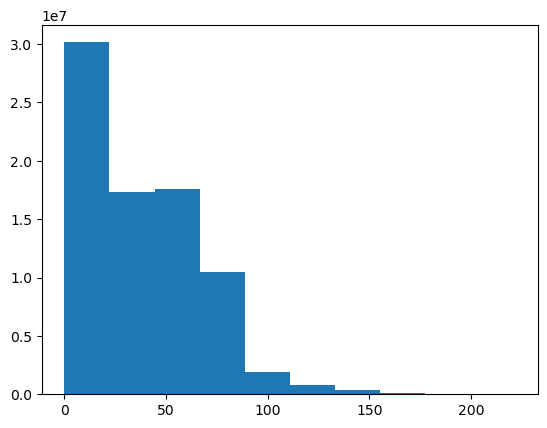

In [ ]:
plt.hist(oriExp_inputs.flatten())

# Full Optimization Process

Now we can get to the optimization process. To do this we'll need some helper functions first.

## Set Up Parameter Evaluation Process

First, let's create some functions that will simplify the process:

**SSN Helpers**

`build_network`: defines a process for building a new network in a single line.

`run_simulation`: defines a process for running a simulation in a single line.

**Model Evaluation**

Then we'll need to evaluate the model. We'll do this using

`feasibility_check`: implements a quick check on the outputs of the model to test if its a feasible paramter set.

`evaluate_parameters`: defines a process that takes in a set of paramters and returns the cost and feasibility. This function calls `build_network` to build a `n_inst` SSNs with random initializations based on the current parameters. Then it runs simulations given the inputs by calling `run_simulation`. It then determines if the parameter set is feasible by calling the `feasibility_check`. Finally, it computes the feasibility across instances and computes the cost with help from `SSN_utils.compute_cost` which allows you to specify a cost function. We use KL-dviergence for our cost function.

**Cost Function**

The cost function is how we'll evaluate the model fit to data. We're working with positive-valued distributions, and we want the model generated-distributions to match the data distributions. One metric for comparing the similarity of distributions is the **[Kullback-Leibler divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence)**. It computes the excess suprisal of observing one distribution (P) given you are expecting the other distribution (Q) instead of the former (P). It is written as:

\begin{equation}
D_{KL}(P || Q) = \sum_{x \in \mathcal{X}} P(x)\text{log}\frac{P(x)}{Q(x)}
\end{equation}

**Baysian Optimization**

The optimization approach is similar to that described in [BayesianOptimization.ipynb](BayesianOptimization.ipynb) with one critical difference, a feasibility function estimated by a second Gaussian process now influences the acquisition function. Before the acquisition function was given by the expected improvement (EI):

\begin{equation}
a(\theta) = (f_- - \hat{\mu}(\theta)) \Phi\left(\frac{f_{-}-\hat{\mu}(\theta)}{\hat{\sigma}(\theta)}\right) + \hat{\sigma}(\theta)\phi\left(\frac{f_{-}-\hat{\mu}(\theta)}{\hat{\sigma}(\theta)}\right)
\end{equation}

where the first term represented exploitation and the second term represented exploration.

We now add to this a feasibility modifier, which adjust the acquitions function by applying a value between zero and one to the EI that represents the probability of feasibility:

\begin{equation}
a(\theta) = \Phi\left(\frac{\hat{\mu_g}(\theta)-0.5}{\hat{\sigma_g}(\theta)}\right) \left((f_- - \hat{\mu}(\theta)) \Phi\left(\frac{f_{-}-\hat{\mu}(\theta)}{\hat{\sigma}(\theta)}\right) + \hat{\sigma}(\theta)\phi\left(\frac{f_{-}-\hat{\mu}(\theta)}{\hat{\sigma}(\theta)}\right)\right)
\end{equation}

where $\Phi\left(\frac{\hat{\mu_g}(\theta)-0.5}{\hat{\sigma_g}(\theta)}\right)$ is the normal cummulative distribution functions (CDF) of the z-scored feasibility values from the feasibility GP.


In [ ]:
# Function to build the SSN network
def build_network(config_file, theta, param_keys, seed=0, fix_nodes=False, node_seed=0):
    ssn = SSN("ei_model", verbose=False)
    ssn.load_config(config_file)
    if not fix_nodes:
        ssn.set_rand_seed(seed=seed)
    else:
        ssn.set_rand_seed(seed=node_seed)
    
    # Map theta values to SSN parameters
    for i, (param_name, path) in enumerate(param_keys.items()):
        d = ssn.parameters
        for key in path[:-1]:
            d = d[key]
        final_key = path[-1]
        d[final_key] = theta[i]

    
    # Build the network
    ssn.add_nodes()
    ssn.add_edges(seed=seed)
    return ssn

# Function to run a simulation on the SSN model
def run_simulation(ssn, input_matrix, scale=1.0):
    ssn.inputs = input_matrix
    ssn.connect_inputs()
    ssn.node_types['c'] = scale
    ssn.nodes['c'] = scale
    ssn.run()
    return ssn

def evaluate_parameters(
    theta,
    param_map,
    ground_truth_data,
    input_data,
    n_inst=5,
    seed=0,
    fix_seed=False,
    **kwargs
):
    """
    Returns (feas_value, cost_value).
    - feas_value: e.g. fraction of 'n_inst' runs that remain stable
    - cost_value: if feasible (>0), do cost. If all are infeasible, cost=large?
    """ 

    # Each condition: run simulation, gather result
    # We'll store results, then compare with ground_truth_data
    # For demonstration, assume you combine them into a single array 
    # of shape [Nnodes x Nconditions].
    
    # Load kwargs
    config_file = kwargs.get('config_file','config.json')
    scale = kwargs.get('scale',1.0)
    threshold = kwargs.get('feas_threshold',1e5)
    fix_nodes = kwargs.get('fix_nodes',False)
    node_seed = kwargs.get('node_seed',0)
    bin_method = kwargs.get('bin_method','fd')
    debug = kwargs.get('debug',False)
    cost_func = kwargs.get('cost_func',SSN_utils.kl_divergence)
    
    # Set scale
    if isinstance(scale, (int, float)):  # Check if scale is a number
        scale = [scale] * len(input_data.keys())  # Repeat the number in a list
    elif isinstance(scale, (list, tuple)):  # Check for array-like types
        pass  # No changes needed
    else:
        raise TypeError("scale must be a number or an array-like object (list or tuple).")

    # We'll accumulate how many runs are stable
    stable_count = 0
    accum_cost = 0.0

    # For each random instantiation
    rng = np.random.default_rng(seed)
    for _ in range(n_inst):
        # Choose random seed
        if not fix_seed:
            subseed = rng.integers(0, 9999999)
        else:
            subseed = seed
        
        if not fix_nodes:
            ssn_model = build_network(config_file, theta, param_map, seed=subseed, fix_nodes=fix_nodes)
        else:
            ssn_model = build_network(config_file, theta, param_map, seed=subseed, fix_nodes=fix_nodes, node_seed=node_seed)
            
        # Print parameters if in debug mode
        if debug:
            print(f"\n--- DEBUG: Model Parameters ---")
            print(f"Seed = {subseed}")
            print(ssn_model.parameters)
        
        # Suppose we run the network once for each condition
        # We'll gather final outputs in all_sims
        Ncond = len(input_data.keys())
        Nneurons = ground_truth_data.shape[0]  # or adapt
        all_sims = np.zeros((Nneurons, Ncond))

        # Quick run
        feas = 1
        for cidx, cond_key in enumerate(input_data):
            inp = input_data[cond_key]
            try:
                ssn_model = run_simulation(ssn_model, inp, scale=scale[cidx])
            except NumericalInstabilityError:
                feas = 0
                break
            # check feasibility right away
            feas = feasibility_check(ssn_model, threshold=threshold)
            if feas == 0:
                # This run is not feasible; no need to compute cost
                break
            # else store final or average
            final_rates = ssn_model.outputs.y[:, -1]  # shape (Nneurons,)
            all_sims[:, cidx] = final_rates

        if feas == 1:
            stable_count += 1
            # Now compute cost for this run
            # e.g. use your cost function:
            run_cost = SSN_utils.compute_cost(all_sims, ground_truth_data, method=bin_method, cost_function=cost_func)
            accum_cost += run_cost
            
        if debug:
            print(f"\n--- DEBUG: Model Feasibility and Cost ---")
            print(f"Feasibility = {feas}")
            if feas == 1:
                print(f"Cost = {run_cost}")

    # fraction feasible across n_inst
    feas_value = stable_count / n_inst

    # cost_value: if fraction feasible > 0, average cost among feasible runs
    # else large cost
    if feas_value > 0:
        avg_cost = accum_cost / stable_count
    else:
        avg_cost = 1e9  # big penalty if all runs fail
        
    if debug:
        # Print a histogram of the entire final output distribution
        flattened = all_sims.ravel()
        hist, bin_edges = np.histogram(flattened, bins=20)
        print(f"\n--- DEBUG: Evaluate Params for theta={theta} ---")
        print(f"Histogram of final outputs (flattened across conditions):")
        print("  bins: ", bin_edges)
        print("  hist: ", hist)
        print(f"Cost Value (sum of losses): {avg_cost:.4f}")

    return feas_value, avg_cost

def feasibility_check(ssn_model, threshold=1e5):
    """
    Return 1 if feasible, 0 if not feasible.
    e.g. check if any firing rates exceed 'threshold'
    """
    # Suppose ssn_model.outputs.y is shape [Nneurons, T], or you can
    # examine partial time steps if you do a short run
    if (ssn_model.outputs.y > threshold).any():
        return 0
    return 1

## Run Optimization

Now we are ready to run the optimization procedure. We'll first set the hyperparameters:
- `n_init=50`; number of randomly initialized parameter sets to estimate prior distribution
- `n_inst=1`; number of model instances to draw on each iteration
- `n_iter=1000`; number of iterations to run
- `seed=42`; random seed for reproducibility

We'll also need to define some other things:
- `param_bounds`; paramter bounds
- `param_map`; names for our parameters and the path to find them in the SSN network config JSON files
- `fix_seed`; True if we want to fix the random seed before creating the network (this is important when we're looking at small networks where small changes can cause large differences in their behaviors)
- `evaluation_kwargs`; some keyword arguments to pass to our evaluation function

We'll create a `bayesopt.py` object called `bo`, which will hold all of our parameter bounds, out parameter map, our evaluation method, and any key word arguments to go along with our evaluation method.

Finally, we'll call `bo.bayesopt` to initiate the optimization process.

In [ ]:
n_init = 50   #number of initial parameterizations to sample
n_inst = 1    #number of model instances per iteration
n_iter = 1000 #number of iterations
seed = 42     #random seed
param_bounds = {'jEE': [0.0,2.0],'jEI': [-2.0,0.0],'jIE': [0.0,2.0],'jII': [-2.0,0.0]} #parameter bounds
param_map = {'jEE': ('edges','spatial_tuning','E<-E','j'), #map to parameters in network JSON
            'jEI': ('edges','spatial_tuning','E<-I','j'),
            'jIE': ('edges','spatial_tuning','I<-E','j'),
            'jII': ('edges','spatial_tuning','I<-I','j'),
            }
fix_seed = True #if True, fix the random seed when creating the network
evaluation_kwargs = { #key word arguments to evaluation function
            'config_file': os.path.join(mainDir,'config.20250219grid.flexCRF.json'), #SSN config file
            'scale': [1.0, 0.01, 1.0, 0.01],                                         #scale factor of inputs
            'feas_threshold': 1e5,                                                   #firing rate threshold for feasibility
            'bin_method': 100,                                                       #method for binning outputs
            'debug': False,                                                          #debug mode
            'cost_func': SSN_utils.kl_divergence,                                    #cost function
            'n_candidates': 10000                                                    #number of candidate parameterizations to consider in the acquisition function on each iteration
            }

# Initialize object
bo = bayesopt(param_bounds, param_map, user_evaluate=evaluate_parameters, evaluation_kwargs=evaluation_kwargs)

# Optimize
best_params = bo.bayesopt(n_init=n_init, 
            n_inst=n_inst, 
            n_iter=n_iter, 
            random_state=seed, 
            acquisition_func=SSN_utils.expected_improvement, 
            ground_truth_data=target_data_mat, 
            input_data=input_data,
            fix_seed=fix_seed,
            use_feas=True,
            verbose=False
            )

SSN WARNING: No input configuration file specified in config. Using default input configuration.
SSN WARNING: Input configuration file not found at ./inputs/flexCRF/./inputs/config.inputs.json. Using default input configuration.
SSN Warning: No input stimulus parameters found. Assuming input duration and time step match runtime parameters.
SSN WARNING: No input configuration file specified in config. Using default input configuration.
SSN WARNING: Input configuration file not found at ./inputs/flexCRF/./inputs/config.inputs.json. Using default input configuration.
SSN Warning: No input stimulus parameters found. Assuming input duration and time step match runtime parameters.
SSN WARNING: No input configuration file specified in config. Using default input configuration.
SSN WARNING: Input configuration file not found at ./inputs/flexCRF/./inputs/config.inputs.json. Using default input configuration.
SSN Warning: No input stimulus parameters found. Assuming input duration and time step 

KeyboardInterrupt: 

## Evaluate Results

Let's look at how we did. First, we can check the minimum cost history by looking at the `bayesopt` attribute `bo.history_minCosts`.

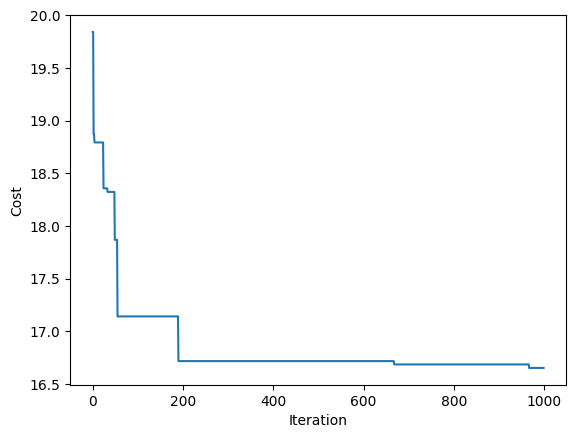

In [ ]:
# Plot Cost History

plt.figure()
plt.plot(bo.history_minCosts)
plt.xlabel("Iteration")
plt.ylabel("Cost")
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_costVstime.png"
plt.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

Now let's visualize our solution in parameter space. First we'll define what our target parameter set was from the model used to generate the sample data. Then we'll plot the Gaussian Process estimate in 2D slices of parameter space. We have a 4D space so we'll take a slice through the minimum along each of 6 orthogonal planes.

Bayesopt has a build-in function for plotting 2D slices in parameter space called `bo.plot_gp_slice_2d`. It takes as input the parameter names you want to plot, and defaults to plotting the plane cnetered on the minimum.

In [ ]:
true_param = {'jEE': 0.5, 'jEI': -0.46, 'jIE': 1.9, 'jII': -0.445}

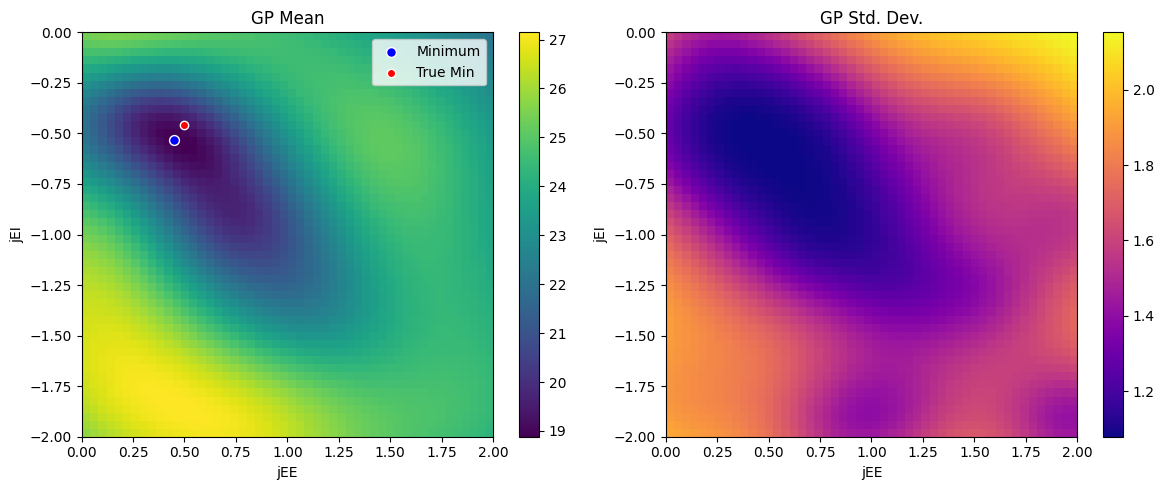

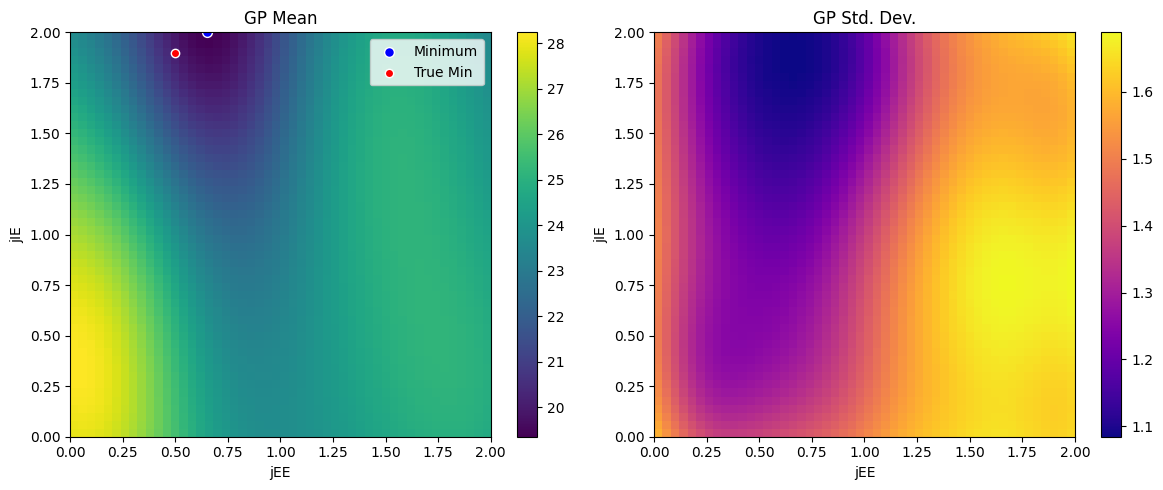

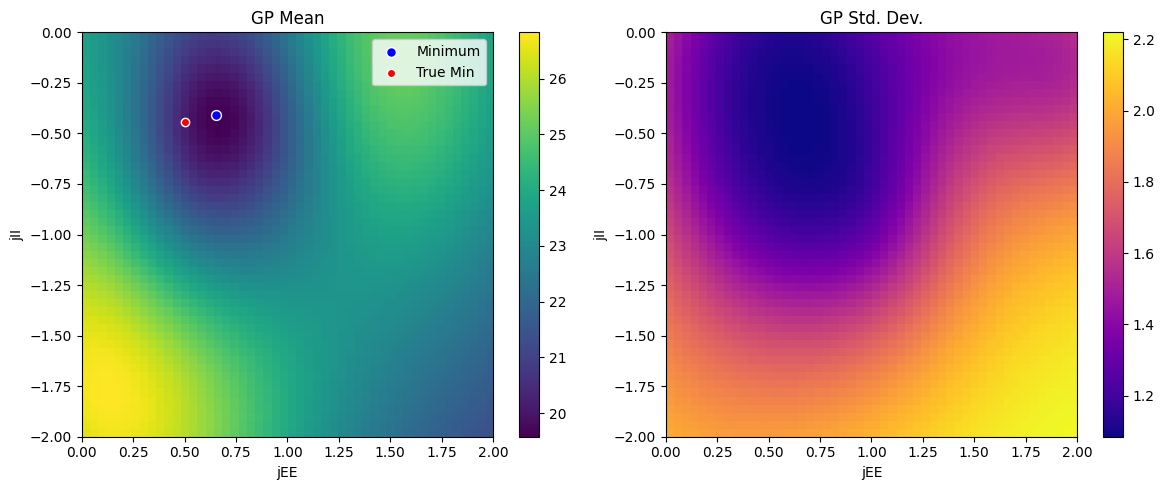

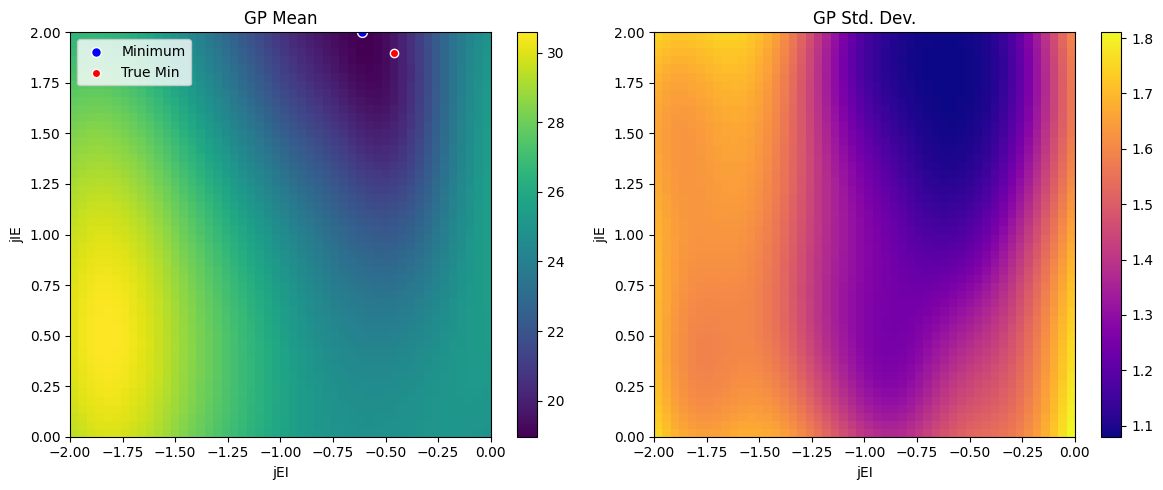

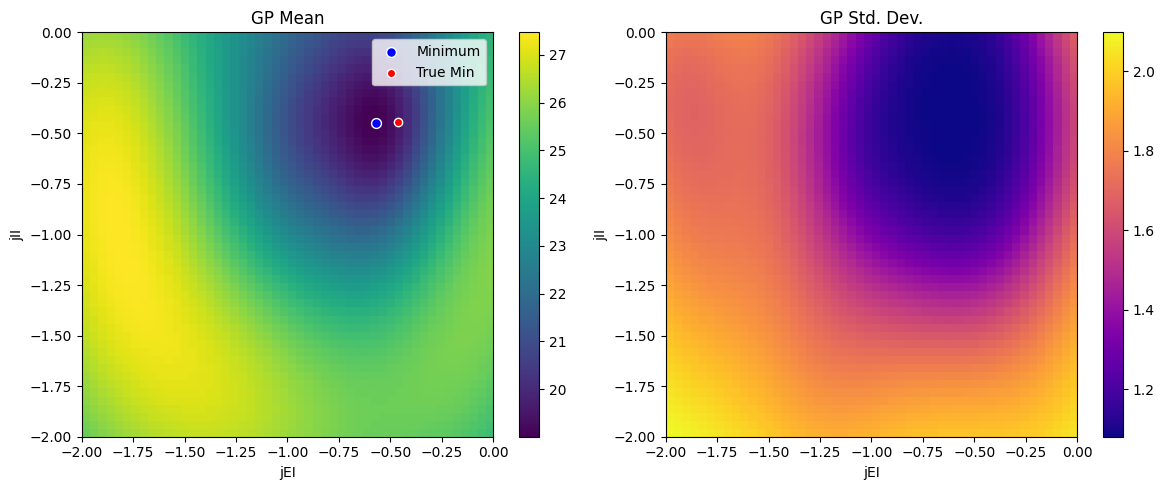

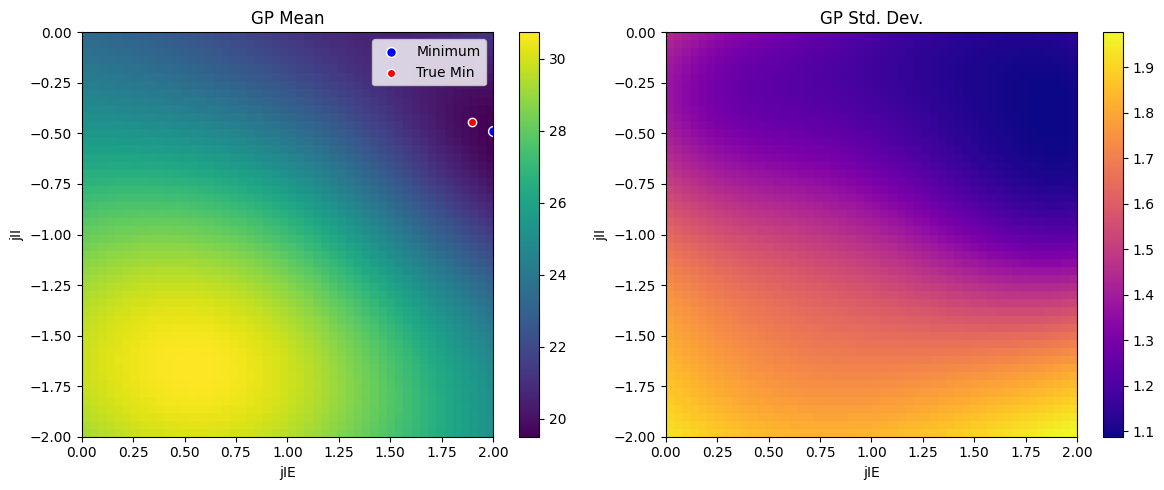

In [ ]:
#%% Visualize
#jEE vs jEI
fig, ax = bo.plot_gp_slice_2d(['jEE', 'jEI'])
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEExjEI.png"
ax[0].scatter(true_param['jEE'], true_param['jEI'], c='r', edgecolor='white', label='True Min')
ax[0].legend()
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jEE vs jIE
fig, ax = bo.plot_gp_slice_2d(['jEE', 'jIE'])
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEExjIE.png"
ax[0].scatter(true_param['jEE'], true_param['jIE'], c='r', edgecolor='white', label='True Min')
ax[0].legend()
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jEE vs jII
fig, ax = bo.plot_gp_slice_2d(['jEE', 'jII'])
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEExjII.png"
ax[0].scatter(true_param['jEE'], true_param['jII'], c='r', edgecolor='white', label='True Min')
ax[0].legend()
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jEI vs jIE
fig, ax = bo.plot_gp_slice_2d(['jEI', 'jIE'])
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEIxjIE.png"
ax[0].scatter(true_param['jEI'], true_param['jIE'], c='r', edgecolor='white', label='True Min')
ax[0].legend()
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jEI vs jII
fig, ax = bo.plot_gp_slice_2d(['jEI', 'jII'])
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEIxjII.png"
ax[0].scatter(true_param['jEI'], true_param['jII'], c='r', edgecolor='white', label='True Min')
ax[0].legend()
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jIE vs jII
fig, ax = bo.plot_gp_slice_2d(['jIE', 'jII'])
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jIExjII.png"
ax[0].scatter(true_param['jIE'], true_param['jII'], c='r', edgecolor='white', label='True Min')
ax[0].legend()
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

We can see that the discovered parameters (blue) fall near the true parameters (red), so we were converging on the correct solution. The left side shows the mean of the GP and the right side shows the st. dev. of the GP.

Now let's visualize the feasibility GP. We can also use `bo.plot_gp_slice_2d` for this by adding a keyword argument `gp=bo.gp_feas`. This sets the GP to be plotted to the feasibility GP which is found under `bo.gp_feas`.

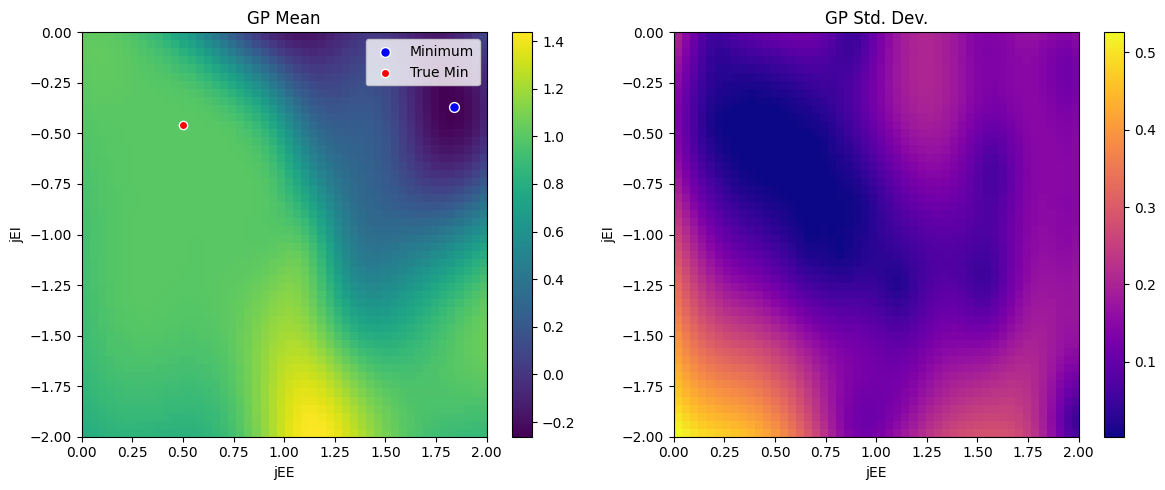

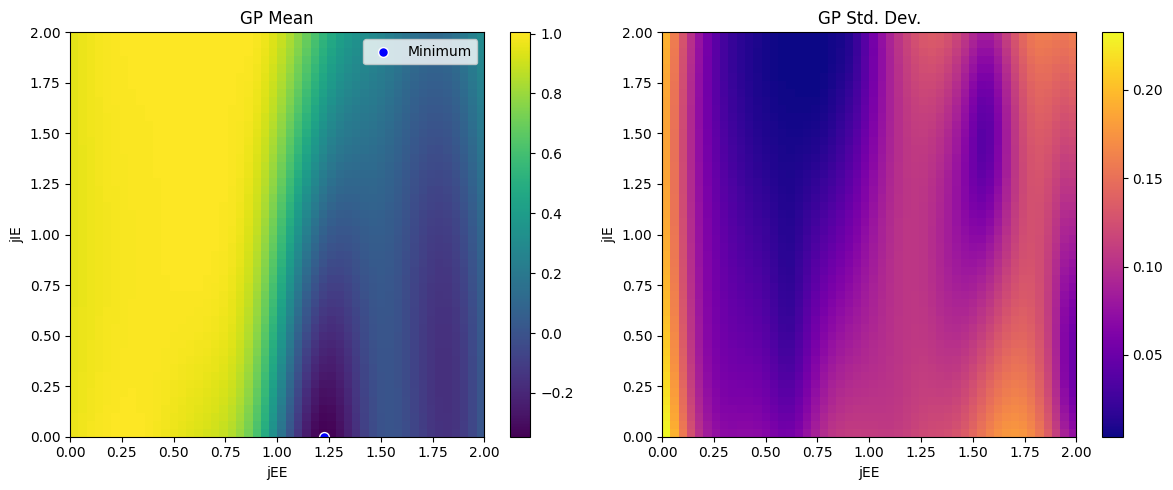

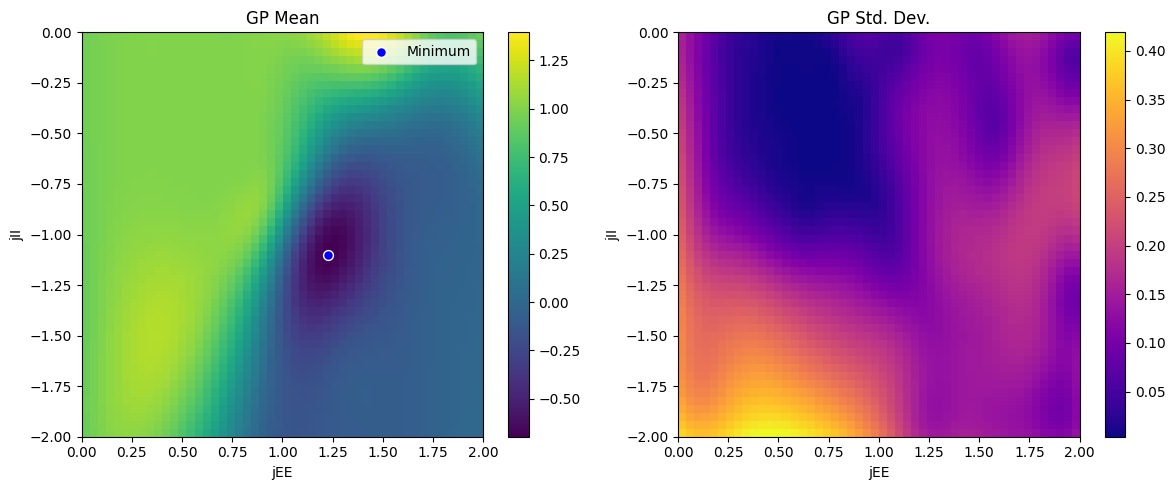

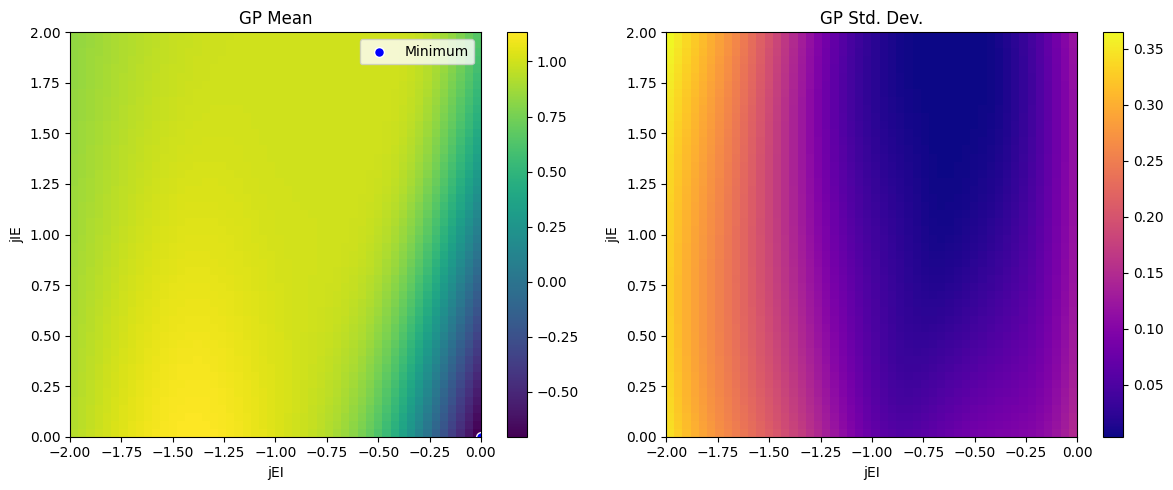

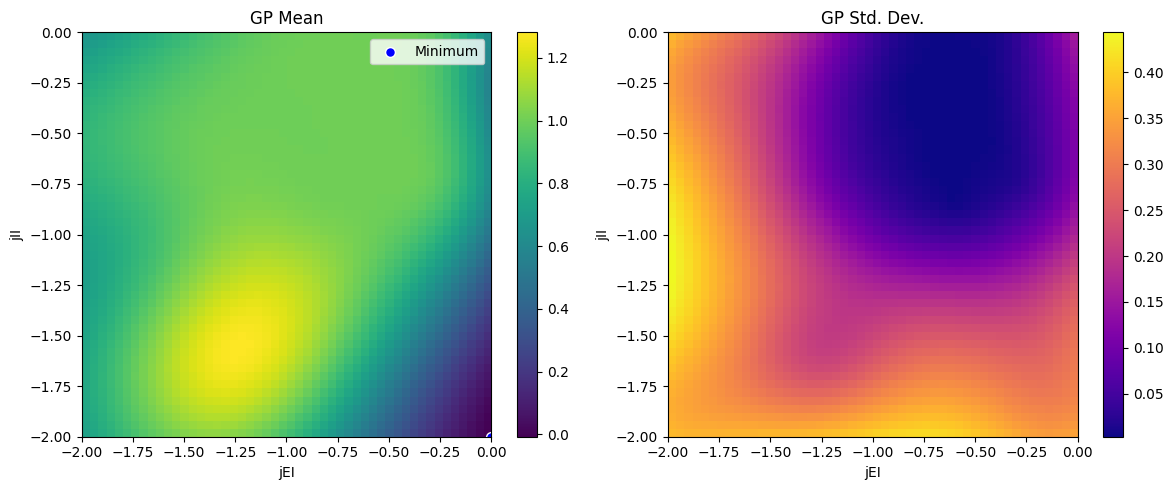

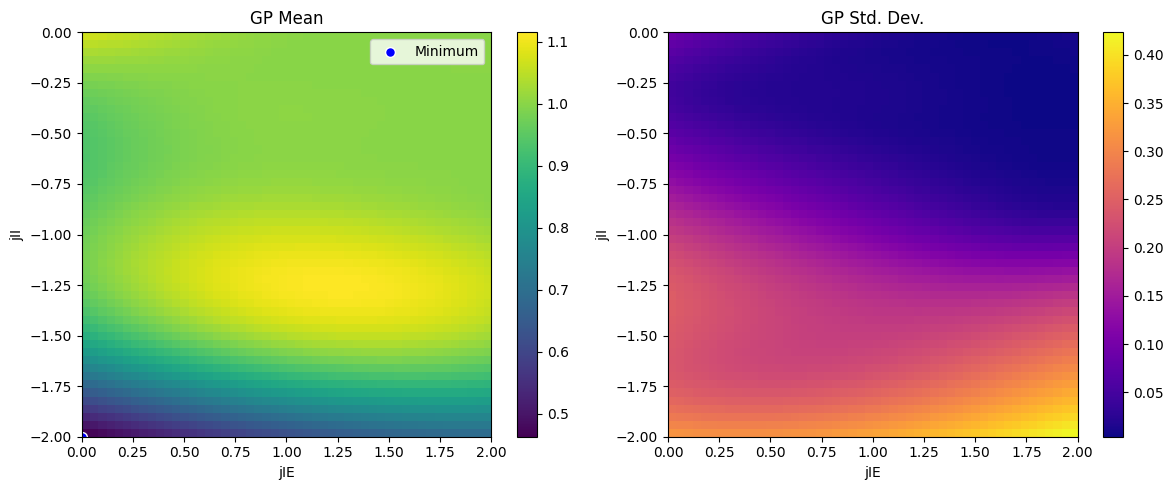

In [ ]:
#%% Visualize
#jEE vs jEI
fig, ax = bo.plot_gp_slice_2d(['jEE', 'jEI'], gp=bo.gp_feas)
save_str = "KLfeasibility"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEExjEI.png"
ax[0].scatter(true_param['jEE'], true_param['jEI'], c='r', edgecolor='white', label='True Min')
ax[0].legend()
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jEE vs jIE
fig, ax = bo.plot_gp_slice_2d(['jEE', 'jIE'], gp=bo.gp_feas)
save_str = "KLfeasibility"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEExjIE.png"
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jEE vs jII
fig, ax = bo.plot_gp_slice_2d(['jEE', 'jII'], gp=bo.gp_feas)
save_str = "KLfeasibility"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEExjII.png"
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jEI vs jIE
fig, ax = bo.plot_gp_slice_2d(['jEI', 'jIE'], gp=bo.gp_feas)
save_str = "KLfeasibility"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEIxjIE.png"
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jEI vs jII
fig, ax = bo.plot_gp_slice_2d(['jEI', 'jII'], gp=bo.gp_feas)
save_str = "KLfeasibility"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jEIxjII.png"
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

#jIE vs jII
fig, ax = bo.plot_gp_slice_2d(['jIE', 'jII'], gp=bo.gp_feas)
save_str = "KLfeasibility"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_heatmap_jIExjII.png"
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

We're now showing the minimum for the feasibility function, which we don't expect to be the same as the minimum of the cost. Lower feasibility values indicate regions that are less likely to pass the feasibility test on any given model instance.

## Save Training Run

Let's save the results. We'll write this as a joblib file.

In [ ]:
from joblib import dump, load
from datetime import datetime

# Create a filename with current date and time
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"run_{timestamp}.joblib"


# Save
dump(bo, os.path.join(mainDir,'training_runs/20250219grid/',filename))

['./training_runs/20250219grid/run_20250702_072218.joblib']

## Trace Parameter Choice

We can do a bit more analysis to see how the model changed over training.

We expect that model should get closer and closer to the true minimum as training progresses. Let's see if this is the case. We can plot the parameter samples as a scatter plot in parameter space. We'll color code the scatter plot according to the iteration during training. Darker indicates later in training.

We can get the training history through the bayesopt attribute `bo.history_params`.

/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_81398/659539167.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap)(color_vals)
/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_81398/659539167.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


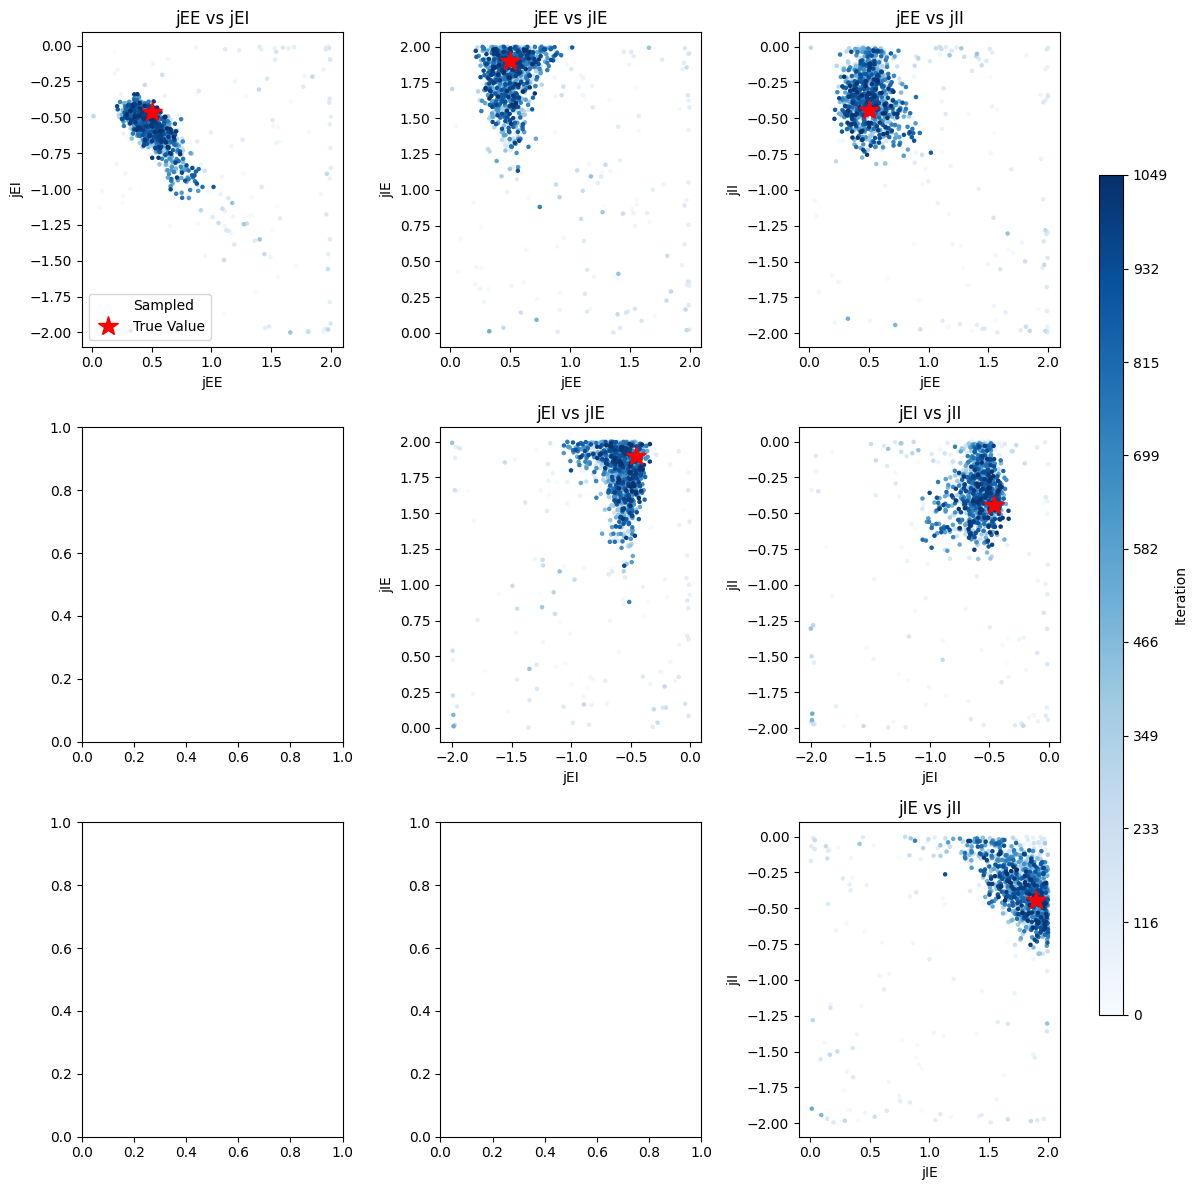

In [ ]:
from itertools import combinations


def plot_param_slices(history_params, true_params, param_names=None, cmap='viridis', marker_size=5):
    """
    Visualize 2D slices of parameter choices over time from a Bayesian Optimization run.

    Parameters:
    - history_params: list of np.ndarray, each array of shape (n_params,)
    - true_params: list or np.ndarray of true parameter values of length n_params
    - param_names: list of str, optional names for parameters
    - cmap: str, name of matplotlib colormap
    """
    history_params = np.array(history_params)
    true_params = np.array(true_params)
    n_params = history_params.shape[1]

    if param_names is None:
        param_names = [f'param_{i}' for i in range(n_params)]

    color_vals = np.linspace(0, 1, len(history_params))
    colors = plt.cm.get_cmap(cmap)(color_vals)

    fig, axes = plt.subplots(nrows=n_params-1, ncols=n_params-1, figsize=(4*(n_params-1), 4*(n_params-1)))
    fig.subplots_adjust(right=0.9)

    for i, j in combinations(range(n_params), 2):
        ax = axes[i, j-1] if n_params > 2 else axes

        # scatter with color coding by iteration
        sc = ax.scatter(history_params[:, i], history_params[:, j], c=range(len(history_params)), s=marker_size, cmap=cmap, label='Sampled', vmin=0, vmax=len(history_params)-1)
        ax.plot(true_params[i], true_params[j], 'r*', markersize=15, label='True Value')

        ax.set_xlabel(param_names[i])
        ax.set_ylabel(param_names[j])
        ax.set_title(f'{param_names[i]} vs {param_names[j]}')

        if i == 0 and j == 1:
            ax.legend()

    # add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_ticks(np.linspace(0, len(history_params)-1, min(len(history_params), 10), dtype=int))
    cbar.set_label('Iteration')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()
    
    return fig, ax

#Discritize colormap for visual clarity
discretize = False
if discretize:
    iteration_bins = (np.arange(len(bo.history_params)) // 200).astype(int)

    import matplotlib.colors as mcolors
    from matplotlib.cm import get_cmap

    n_bins = iteration_bins.max() + 1  # number of discrete bins
    cmap = get_cmap('Blues', n_bins)   # discretized colormap
    norm = mcolors.BoundaryNorm(boundaries=np.arange(n_bins+1)-0.5, ncolors=n_bins)
else:
    cmap = 'Blues'

fig, ax = plot_param_slices(bo.history_params, true_params=[true_param[i] for i in true_param.keys()], param_names=[i for i in true_param.keys()], cmap=cmap)
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_paramSelection.png"
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

Immediately, we see that model parameters cluster around the true parameter set indicated with the star. This indicates that as the model was trained, it moved closer toward the indended target. We can also see a lot of dark dots in this region, suggesting that the model stuck around this area late in training.

## Visualize Feasibility of Samples

We can try the same kind of visualization, but not color code by feasibility. we should see that feasible solutions show up in orange and infeasible solutions in black.

We can get the feasibility history by using the bayesopt attribute `bo.history_feas`.

/var/folders/j3/j5br2dzs4sqgtgbf144x87c40000gs/T/ipykernel_81398/139222499.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


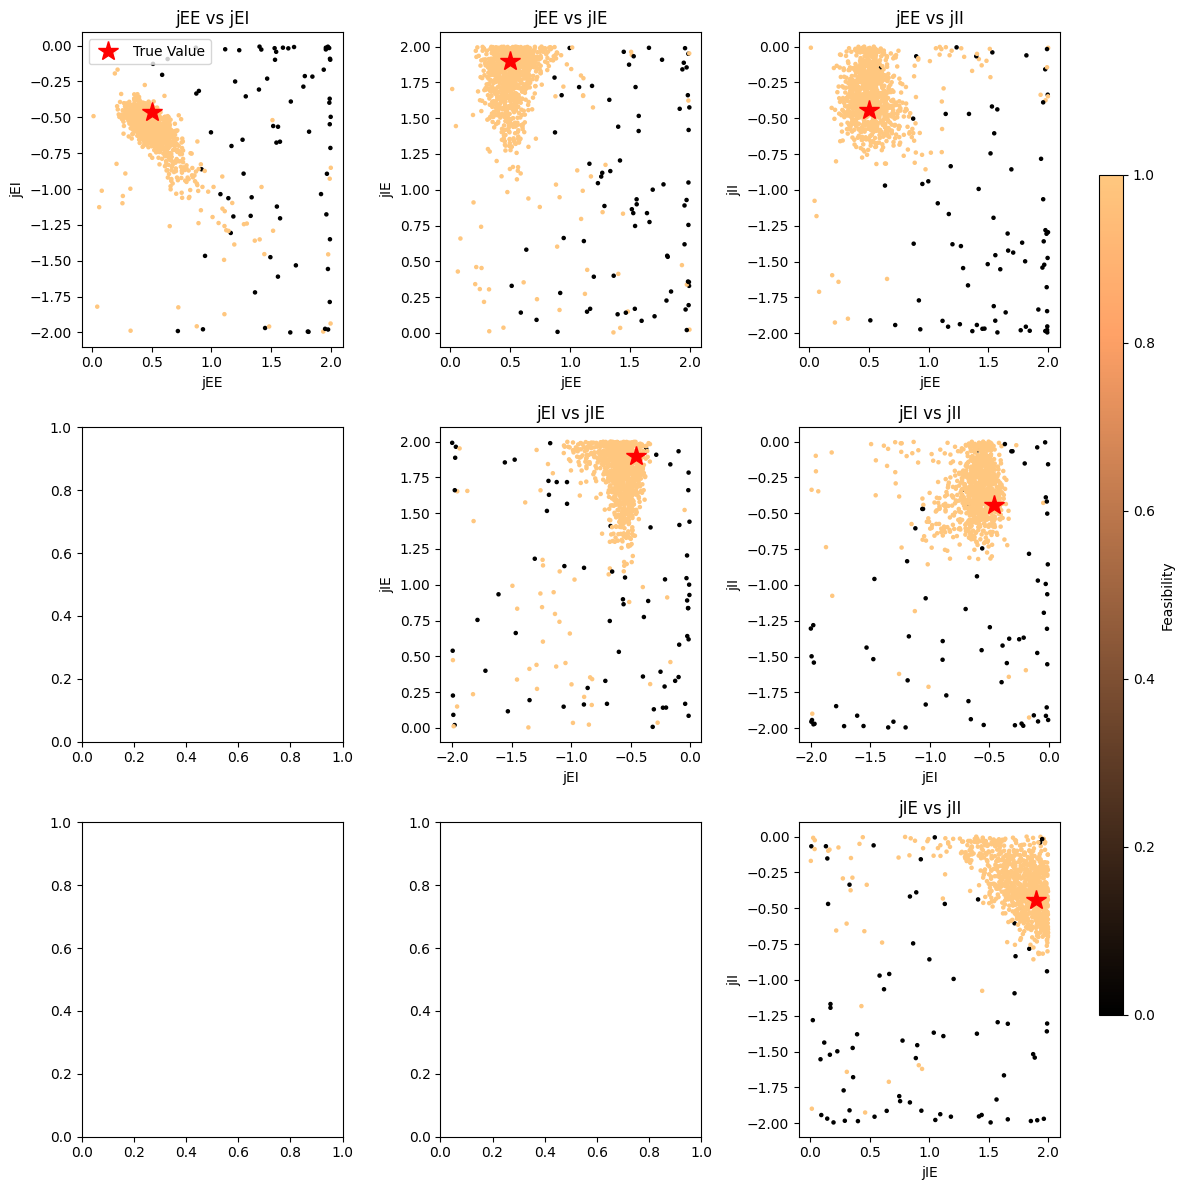

In [ ]:
def plot_feasibility_slices(history_params, history_feas, true_params, param_names=None, cmap='gray', marker_size=5):
    """
    Visualize 2D slices of parameter choices with feasibility coloring.

    Parameters:
    - history_params: list of np.ndarray, each array of shape (n_params,)
    - history_feas: list or np.ndarray of feasibility values in [0, 1], same length as history_params
    - true_params: list or np.ndarray of true parameter values of length n_params
    - param_names: list of str, optional names for parameters
    - cmap: str, name of matplotlib colormap (default: 'gray')
    """
    history_params = np.array(history_params)
    history_feas = np.array(history_feas)
    true_params = np.array(true_params)
    n_params = history_params.shape[1]

    if param_names is None:
        param_names = [f'param_{i}' for i in range(n_params)]

    fig, axes = plt.subplots(nrows=n_params-1, ncols=n_params-1, figsize=(4*(n_params-1), 4*(n_params-1)))
    fig.subplots_adjust(right=0.9)

    for i, j in combinations(range(n_params), 2):
        ax = axes[i, j-1] if n_params > 2 else axes

        # scatter with feasibility coloring
        sc = ax.scatter(history_params[:, i], history_params[:, j], c=history_feas, s=marker_size, cmap=cmap, vmin=0, vmax=1)
        ax.plot(true_params[i], true_params[j], 'r*', markersize=15, label='True Value')

        ax.set_xlabel(param_names[i])
        ax.set_ylabel(param_names[j])
        ax.set_title(f'{param_names[i]} vs {param_names[j]}')

        if i == 0 and j == 1:
            ax.legend()

    # add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label('Feasibility')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()
    
    return fig, ax


# Use
fig, ax = plot_feasibility_slices(bo.history_params, bo.history_feas, true_params=[true_param[i] for i in true_param.keys()], param_names=[i for i in true_param.keys()], cmap='copper')
save_str = "KLfeasibility"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_paramSelection.png"
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

We are able to see that the model clustered around the true parameterization are generally feasible. Large portions of the parameter space are infeasible, but the optimization process was less likely to choose points in these regions which is why they are more sparsely populated.

## Plot Euclidean Distance from True Min

Lastly, a good proxy for the true model fit can be the Euclidean distance between the found parameters and the target parameters. If the cost function is a good proxy for the distance between the found parameters and the true parameters, we should see both go down together.

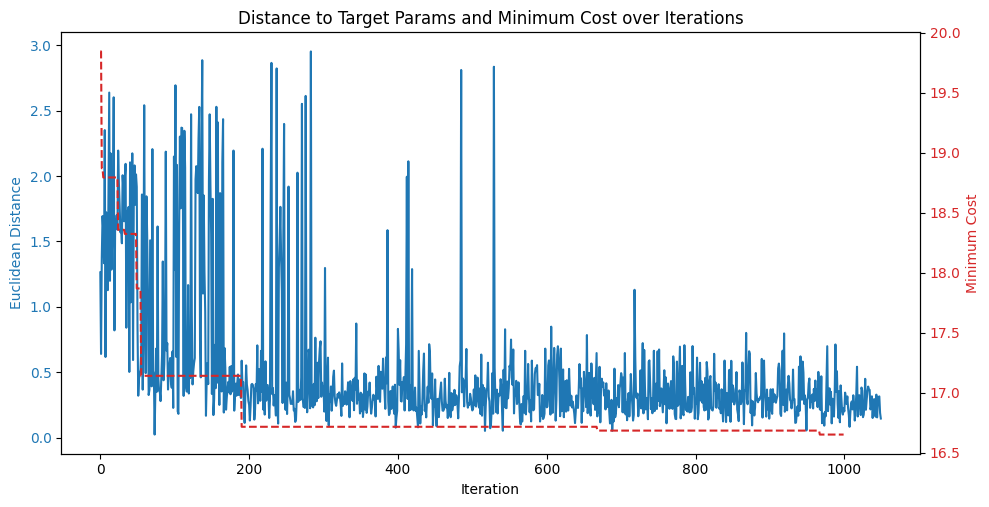

In [ ]:
def plot_distance_and_cost(history_params, history_minCosts, target_params):
    """
    Plot the Euclidean distance to target parameters and minimum cost over iterations.

    Parameters:
    - history_params: list of np.ndarray, each array of shape (n_params,)
    - history_minCosts: list or np.ndarray of minimum cost values per iteration
    - target_params: list or np.ndarray of target parameter values to compare against
    """
    history_params = np.array(history_params)
    history_minCosts = np.array(history_minCosts)
    target_params = np.array(target_params)

    distances = np.linalg.norm(history_params - target_params, axis=1)

    fig, ax1 = plt.subplots(figsize=(10, 5))

    color1 = 'tab:blue'
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Euclidean Distance', color=color1)
    ax1.plot(distances, color=color1, label='Distance to True Params')
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('Minimum Cost', color=color2)
    ax2.plot(history_minCosts, color=color2, linestyle='--', label='Min Cost')
    ax2.tick_params(axis='y', labelcolor=color2)

    fig.tight_layout()
    plt.title('Distance to Target Params and Minimum Cost over Iterations')
    plt.show()
    
    return fig, ax

# Example usage:
fig, ax = plot_distance_and_cost(bo.history_params, bo.history_minCosts, target_params=[true_param[i] for i in true_param.keys()])
save_str = "KLdiv"
save_str += f"_binMethod={evaluation_kwargs['bin_method']}"
save_str += f"_fixNodes={evaluation_kwargs['fix_nodes']}"
save_str += f"_Ninit={n_init}"
save_str += f"_maxIter={n_iter}"
save_str += f"Ninst={n_inst}"
save_str += f"randomState={seed}"
save_str += f"nodeSeed={evaluation_kwargs['node_seed']}"
save_str += f"_EuclideanDist.png"
fig.savefig(os.path.join(mainDir,'plots/20250219grid/bayesopt/',save_str))

In blue is the Euclidean distance between the sampled paramterization and the true parameterization over iterations. It's noisy because the process trades off between exploitation of low-estimated cost regions and exploration of high-uncertainty regions. However, the general trend is downwards as the model moves toward the intended target.

In red is the minimum cost for each iteration. This also decreases over iterations concurrently with the Euclidean distance. However, around 200 iterations, both the distance and cost level off. This is likely due to the model reaching a basin in which the sampling noise and noise in the model evaluations makes it more difficult to find a gradient. That is, within certain bounds, the model produces results that are not significantly different than the data. Within this region, improvements are more likely driven by randomly happening upon better parameter sets.